In [3]:
import pandas as pd

In [4]:
df = pd.read_csv("laptop_price.csv", encoding = "latin-1")

In [5]:
df

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,1316,Lenovo,Yoga 500-14ISK,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,638.00
1299,1317,Lenovo,Yoga 900-13ISK,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16GB,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,1499.00
1300,1318,Lenovo,IdeaPad 100S-14IBR,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,229.00
1301,1319,HP,15-AC110nv (i7-6500U/6GB/1TB/Radeon,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,764.00


In [6]:
df = df.drop("Product", axis=1)

In [7]:
df = df.join(pd.get_dummies(df.Company))
df = df.drop("Company", axis=1)

In [8]:
df = df.join(pd.get_dummies(df.TypeName))
df = df.drop("TypeName", axis=1)

In [9]:
df

,laptop_ID,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros,...,Samsung,Toshiba,Vero,Xiaomi,2 in 1 Convertible,Gaming,Netbook,Notebook,Ultrabook,Workstation
0,1,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69,...,False,False,False,False,False,False,False,False,True,False
1,2,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94,...,False,False,False,False,False,False,False,False,True,False
2,3,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00,...,False,False,False,False,False,False,False,True,False,False
3,4,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45,...,False,False,False,False,False,False,False,False,True,False
4,5,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,1316,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,638.00,...,False,False,False,False,True,False,False,False,False,False
1299,1317,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16GB,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,1499.00,...,False,False,False,False,True,False,False,False,False,False
1300,1318,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,229.00,...,False,False,False,False,False,False,False,True,False,False
1301,1319,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,764.00,...,False,False,False,False,False,False,False,True,False,False


In [10]:
df["ScreenResolution"] = df.ScreenResolution.str.split(" ").apply(lambda x: x[-1])
df["Screen Width"] = df.ScreenResolution.str.split("x").apply(lambda x: x[0])
df["Screen Height"] = df.ScreenResolution.str.split("x").apply(lambda x: x[1])

In [11]:
df = df.drop("ScreenResolution", axis=1)

In [12]:
df["CPU Brand"] = df.Cpu.str.split(" ").apply(lambda x: x[0])
df["CPU Frequency"] = df.Cpu.str.split(" ").apply(lambda x: x[-1])

In [13]:
df = df.drop("Cpu", axis=1)

In [14]:
df["CPU Frequency"] = df["CPU Frequency"].str[:-3]

In [15]:
df["Ram"] = df["Ram"].str[:-2]

In [16]:
df["Ram"] =df["Ram"].astype("int")
df["CPU Frequency"] = df["CPU Frequency"].astype("float")

In [17]:
df["Screen Width"] = df["Screen Width"].astype("int")
df["Screen Height"] = df["Screen Height"].astype("int")

In [18]:
df["Memory Amount"] = df.Memory.str.split(" ").apply(lambda x: x[0])
df["Memory Type"] = df.Memory.str.split(" ").apply(lambda x: x[1])

In [19]:
def turn_memory_into_MB(value):
    if "GB" in value:
        return float(value[:value.find("GB")]) * 1024
    elif "TB" in value:    
        return float(value[:value.find("TB")]) * 1024 * 1024

In [20]:
df["Memory Amount"] = df["Memory Amount"].apply(turn_memory_into_MB)


In [21]:
df = df.drop("Memory", axis=1)

In [22]:
df["Weight"] = df["Weight"].str[:-2]

In [23]:
df["Weight"] = df["Weight"].astype("float")

In [24]:
df["GPU Brand"] = df.Gpu.str.split(" ").apply(lambda x: x[0])

In [25]:
df = df.drop("Gpu",axis=1) 

In [26]:
df = df.join(pd.get_dummies(df.OpSys))
df.drop("OpSys", axis=1)

,laptop_ID,Inches,Ram,Weight,Price_euros,Acer,Apple,Asus,Chuwi,Dell,...,GPU Brand,Android,Chrome OS,Linux,Mac OS X,No OS,Windows 10,Windows 10 S,Windows 7,macOS
0,1,13.3,8,1.37,1339.69,False,True,False,False,False,...,Intel,False,False,False,False,False,False,False,False,True
1,2,13.3,8,1.34,898.94,False,True,False,False,False,...,Intel,False,False,False,False,False,False,False,False,True
2,3,15.6,8,1.86,575.00,False,False,False,False,False,...,Intel,False,False,False,False,True,False,False,False,False
3,4,15.4,16,1.83,2537.45,False,True,False,False,False,...,AMD,False,False,False,False,False,False,False,False,True
4,5,13.3,8,1.37,1803.60,False,True,False,False,False,...,Intel,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,1316,14.0,4,1.80,638.00,False,False,False,False,False,...,Intel,False,False,False,False,False,True,False,False,False
1299,1317,13.3,16,1.30,1499.00,False,False,False,False,False,...,Intel,False,False,False,False,False,True,False,False,False
1300,1318,14.0,2,1.50,229.00,False,False,False,False,False,...,Intel,False,False,False,False,False,True,False,False,False
1301,1319,15.6,6,2.19,764.00,False,False,False,False,False,...,AMD,False,False,False,False,False,True,False,False,False


In [27]:
cpu_categories = pd.get_dummies(df["CPU Brand"])  
cpu_categories.columns = [col + "_CPU" for col in cpu_categories.columns]  

df = df.join(cpu_categories)  
df = df.drop("CPU Brand", axis=1)  


In [28]:
gpu_categories = pd.get_dummies(df["GPU Brand"])  
gpu_categories.columns = [col + "_GPU" for col in gpu_categories.columns]  

df = df.join(gpu_categories)  
df = df.drop("GPU Brand", axis=1)  


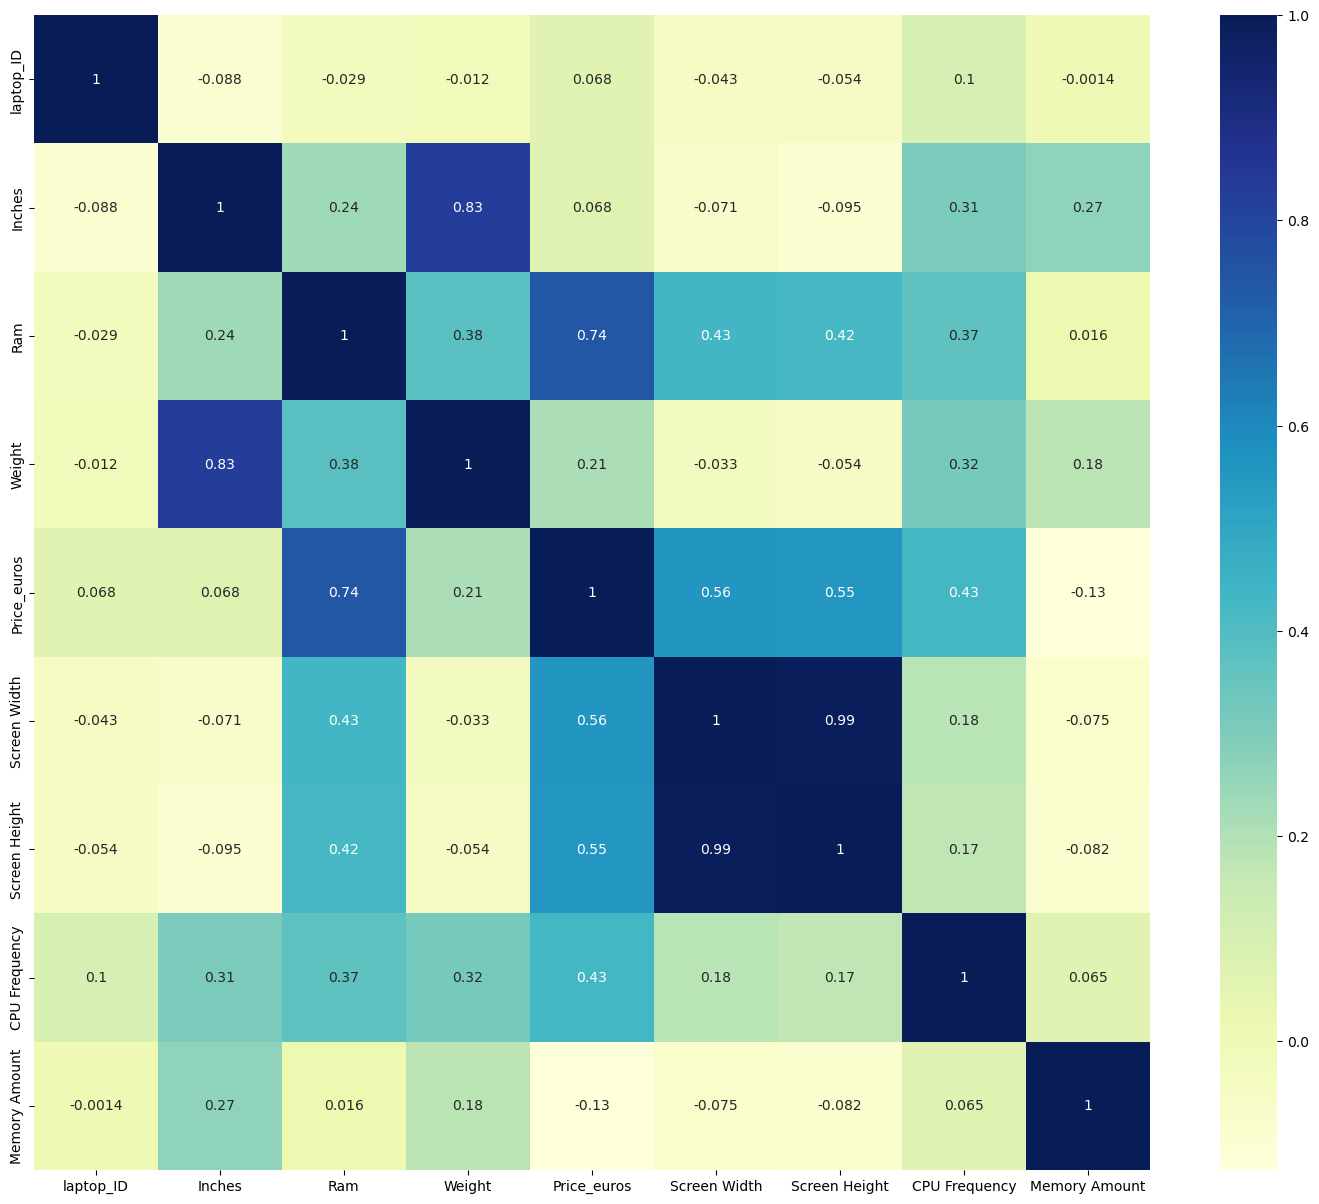

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt


numeric_df = df.select_dtypes(include=['number'])  
plt.figure(figsize=(18, 15))
sns.heatmap(numeric_df.corr(), annot=True, cmap="YlGnBu")
plt.show()


In [30]:
numeric_df = df.select_dtypes(include=['number'])

target_correlations = numeric_df.corr()['Price_euros'].apply(abs).sort_values()


print(target_correlations)


selected_features = target_correlations[-21:].index
selected_features = list(selected_features)


limited_df = df[selected_features]
limited_df

laptop_ID        0.067830
Inches           0.068197
Memory Amount    0.125363
Weight           0.210370
CPU Frequency    0.430293
Screen Height    0.552809
Screen Width     0.556529
Ram              0.743007
Price_euros      1.000000
Name: Price_euros, dtype: float64


,laptop_ID,Inches,Memory Amount,Weight,CPU Frequency,Screen Height,Screen Width,Ram,Price_euros
0,1,13.3,131072.0,1.37,2.3,1600,2560,8,1339.69
1,2,13.3,131072.0,1.34,1.8,900,1440,8,898.94
2,3,15.6,262144.0,1.86,2.5,1080,1920,8,575.00
3,4,15.4,524288.0,1.83,2.7,1800,2880,16,2537.45
4,5,13.3,262144.0,1.37,3.1,1600,2560,8,1803.60
...,...,...,...,...,...,...,...,...,...
1298,1316,14.0,131072.0,1.80,2.5,1080,1920,4,638.00
1299,1317,13.3,524288.0,1.30,2.5,1800,3200,16,1499.00
1300,1318,14.0,65536.0,1.50,1.6,768,1366,2,229.00
1301,1319,15.6,1048576.0,2.19,2.5,768,1366,6,764.00


In [31]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


In [32]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [33]:
X, y = limited_df.drop("Price_euros", axis=1), limited_df["Price_euros"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [34]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)

print(
	f'X_train shape: {X_train.shape}\n'+
	f'y_train shape: {y_train.shape}\n'+
	f'X_test shape:  {X_test.shape}\n'+
	f'y_test shape:  {y_test.shape}'
)

X_train shape: (1042, 8)
y_train shape: (1042,)
X_test shape:  (261, 8)
y_test shape:  (261,)


In [35]:
import numpy as np  

def model_report(model, verbose=True):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    trainScore = model.score(X_train, y_train)
    testScore = model.score(X_test, y_test)
    r2Score = r2_score(y_test, y_pred)
    absoluteError = mean_absolute_error(y_test, y_pred)
    squaredError = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(squaredError)  

    
    n = X_test.shape[0]  
    p = X_test.shape[1]  
    adjusted_r2 = 1 - ((1 - r2Score) * (n - 1) / (n - p - 1))

    if verbose:
        print('Train Score: %f' % trainScore)
        print('Test Score:  %f' % testScore)
        print('R2 Score:    %f' % r2Score)
        print('Mean Absolute Error: %f' % absoluteError)
        print('Mean Squared Error: %f' % squaredError)
        print('Root Mean Squared Error: %f' % rmse)
        print('Adjusted R2: %f' % adjusted_r2)
      
        plt.scatter(y_pred, y_test)
        plt.xlabel('Predicted Values')
        plt.ylabel('True Values')
        plt.show()
        print()
    
    return {
        'train': trainScore,
        'test': testScore,
        'r2score': r2Score,
        'absolute': absoluteError,
        'squared': squaredError,
        'rmse': rmse,
        'adjusted_r2': adjusted_r2
    }


In [36]:
models_dict= {
	'LinearRegression':      LinearRegression(),
	'Lasso':                 Lasso(),
	'Ridge':                 Ridge(),
	'DecisionTreeRegressor': DecisionTreeRegressor(),
	'RandomForestRegressor': RandomForestRegressor(),
	

}
models= [{'name':k, 'obj':v} for k,v in models_dict.items()]

i= 0
for model in models:
        print("Evaluating %s..."%model['name'])
        print("%d/%d models"%(i, len(models)), end='\r')
        model.update(model_report(model['obj'], verbose=False))
        i+= 1
print("%d/%d models evaluated"%(i, len(models)))
print("done")

Evaluating LinearRegression...
Evaluating Lasso...
Evaluating Ridge...
Evaluating DecisionTreeRegressor...
Evaluating RandomForestRegressor...
5/5 models evaluated
done


In [37]:
linear_model = LinearRegression()

In [38]:
linear_model.fit(X_train, y_train)
y_pred = linear_model.predict(X_test)

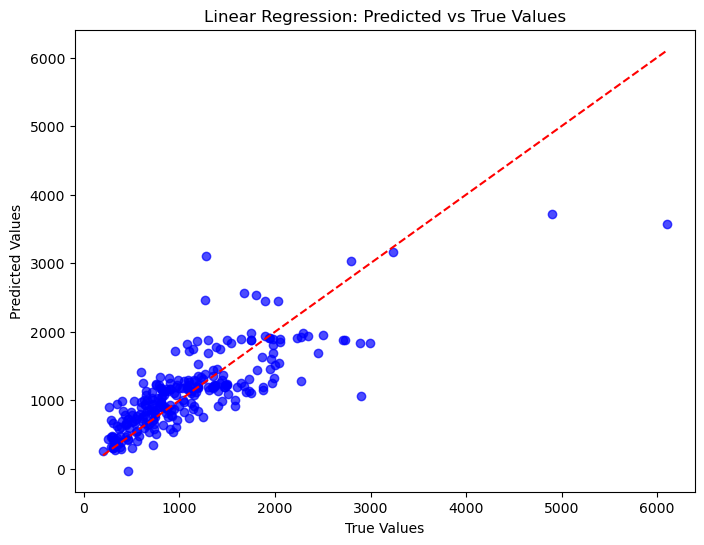

In [39]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('Linear Regression: Predicted vs True Values')
plt.show()

In [40]:
lasso_model = Lasso()

In [41]:
lasso_model.fit(X_train, y_train)
y_pred = lasso_model.predict(X_test)

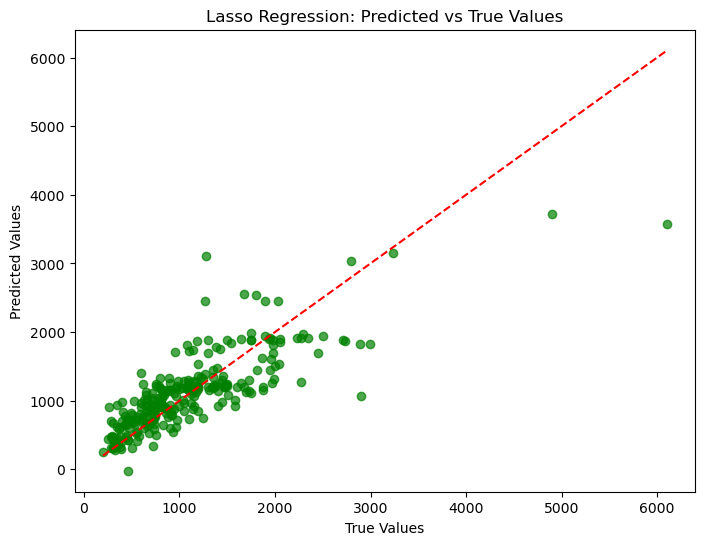

In [42]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('Lasso Regression: Predicted vs True Values')
plt.show()

In [43]:
ridge_model = Ridge()

In [44]:
ridge_model.fit(X_train, y_train)
y_pred = ridge_model.predict(X_test)

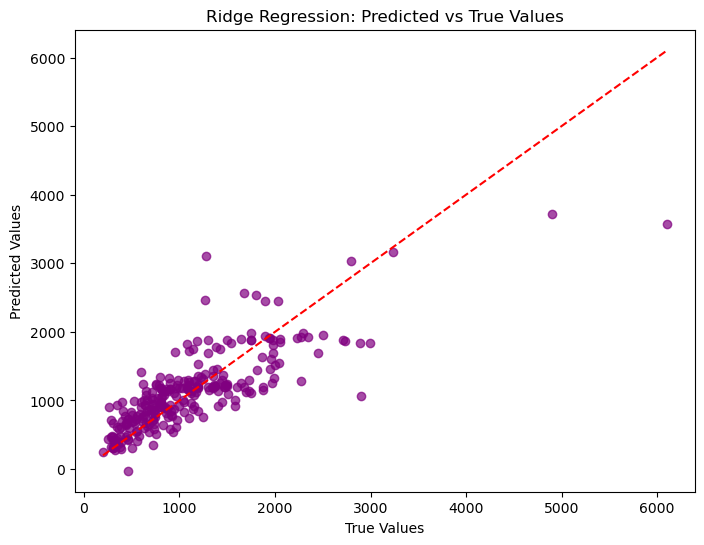

In [45]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') 
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('Ridge Regression: Predicted vs True Values')
plt.show()

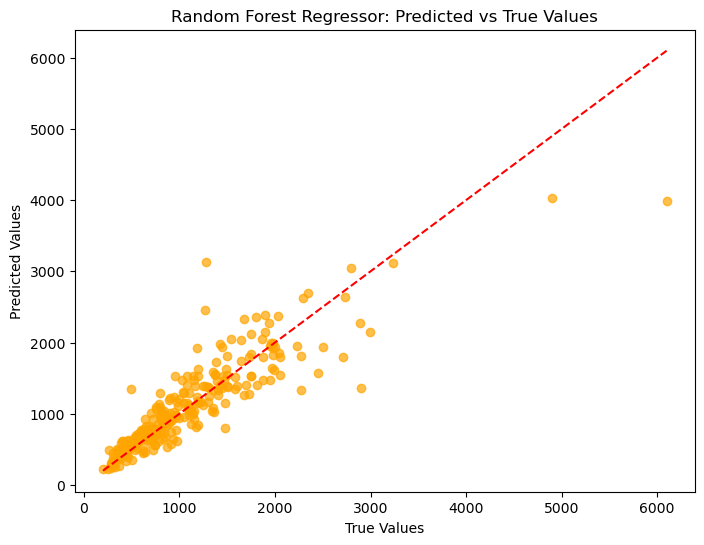

In [46]:
random_forest_model = RandomForestRegressor()


random_forest_model.fit(X_train, y_train)
y_pred = random_forest_model.predict(X_test)


plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='orange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') 
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('Random Forest Regressor: Predicted vs True Values')
plt.show()

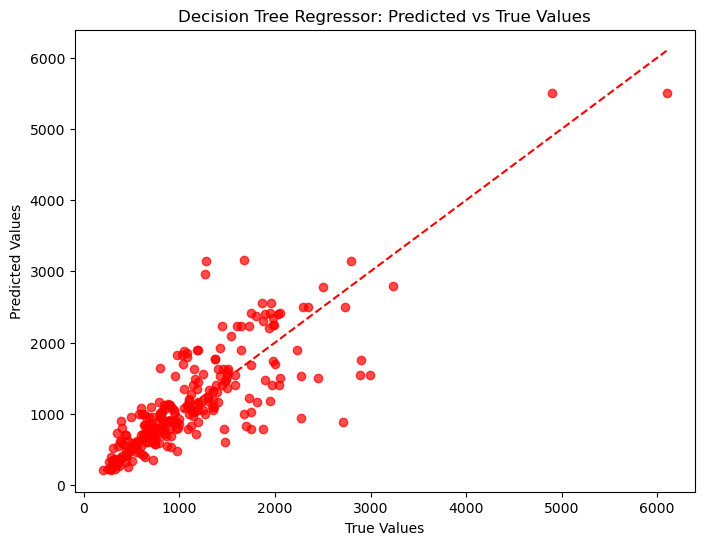

In [47]:
decision_tree_model = DecisionTreeRegressor()


decision_tree_model.fit(X_train, y_train)
y_pred = decision_tree_model.predict(X_test)


plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='red')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('Decision Tree Regressor: Predicted vs True Values')
plt.show()


In [48]:
pd.DataFrame({
	'Algorithm':           [model['name']     for model in models],
	'Train Score':         [model['train']    for model in models],
	'Test Score':          [model['test']     for model in models],
     # 'R2 Score':         [model['r2score']  for model in models], #same as Test Score
	'Mean Absolute Error': [model['absolute'] for model in models],
	'Mean Squared Error':  [model['squared']  for model in models],
    'Root Mean Squared Error': [model['rmse']  for model in models],
    'Adjusted R2': [model.get('adjusted_r2') for model in models],
}).set_index('Algorithm').sort_values(by='Test Score', ascending=False)

,Train Score,Test Score,Mean Absolute Error,Mean Squared Error,Root Mean Squared Error,Adjusted R2
Algorithm,,,,,,
RandomForestRegressor,0.966910,0.777861,210.194482,112830.077579,335.901887,0.770809
DecisionTreeRegressor,1.000000,0.670059,267.446475,167586.003479,409.372695,0.659584
Lasso,0.678510,0.656056,291.427024,174698.209351,417.969149,0.645137
Ridge,0.678551,0.655832,291.634296,174811.976649,418.105222,0.644906
LinearRegression,0.678552,0.655800,291.655742,174828.191974,418.124613,0.644873


In [49]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np


models_hyperparams = {
    'LinearRegression': {
        'model': LinearRegression(),
        'params': {}
    },
    'Lasso': {
        'model': Lasso(),
        'params': {'alpha': [0.01, 0.1, 1.0, 10.0]}
    },
    'Ridge': {
        'model': Ridge(),
        'params': {'alpha': [0.01, 0.1, 1.0, 10.0]}
    },
    'DecisionTreeRegressor': {
        'model': DecisionTreeRegressor(),
        'params': {'max_depth': [5, 10, None], 'min_samples_split': [2, 5, 10]}
    },
    'RandomForestRegressor': {
        'model': RandomForestRegressor(),
        'params': {'n_estimators': [50, 100], 'max_depth': [5, 10, None]}
    }
}


results = []


for model_name, config in models_hyperparams.items():
    model = config['model']
    param_grid = config['params']
    
    
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=5,  
        scoring='r2',  
        n_jobs=-1 
    )
    
   
    grid_search.fit(X_train, y_train)
    
    
    best_model = grid_search.best_estimator_
    best_params = grid_search.best_params_
    
    
    y_pred = best_model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    
    n = X_test.shape[0]  
    p = X_test.shape[1]  
    adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))
    
    
    results.append({
        'model': model_name,
        'best_params': best_params,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2,
        'Adjusted R2': adjusted_r2
    })


results_df = pd.DataFrame(results)
print(results_df)
results_df = pd.DataFrame(results)


best_model_row = results_df.loc[results_df['R2'].idxmax()]


print("Best Model:")
print(f"Model: {best_model_row['model']}")
print(f"Best Parameters: {best_model_row['best_params']}")
print(f"R2: {best_model_row['R2']}")
print(f"Adjusted R2: {best_model_row['Adjusted R2']}")


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.460e+04, tolerance: 5.035e+04
  model = cd_fast.enet_coordinate_descent(


                   model                                 best_params  \
0       LinearRegression                                          {}   
1                  Lasso                              {'alpha': 0.1}   
2                  Ridge                              {'alpha': 1.0}   
3  DecisionTreeRegressor  {'max_depth': 10, 'min_samples_split': 10}   
4  RandomForestRegressor       {'max_depth': 10, 'n_estimators': 50}   

          MAE            MSE        RMSE        R2  Adjusted R2  
0  291.655742  174828.191974  418.124613  0.655800     0.644873  
1  291.632855  174813.793287  418.107394  0.655829     0.644903  
2  291.634296  174811.976649  418.105222  0.655832     0.644906  
3  242.452068  140079.094144  374.271418  0.724214     0.715459  
4  204.686656  108571.856099  329.502437  0.786245     0.779459  
Best Model:
Model: RandomForestRegressor
Best Parameters: {'max_depth': 10, 'n_estimators': 50}
R2: 0.7862449570861805
Adjusted R2: 0.7794590827079639


In [50]:
pivot_cube = pd.pivot_table(
    df, 
    values='Price_euros', 
    index=['CPU Frequency'], 
    columns=['Ram'], 
    aggfunc=[np.mean, np.median, np.std],
)




pivot_cube.columns = ['_'.join(map(str, col)) for col in pivot_cube.columns]
print("Data Cube Table:")
print(pivot_cube)


Data Cube Table:
                   mean_2      mean_4      mean_6       mean_8      mean_12  \
CPU Frequency                                                                 
0.90                  NaN  669.000000         NaN   729.000000          NaN   
1.00                  NaN  603.000000         NaN          NaN          NaN   
1.10           274.816667  363.039302  449.000000   939.650000          NaN   
1.20                  NaN         NaN         NaN  1580.028571          NaN   
1.30                  NaN         NaN         NaN  1557.366667          NaN   
1.44           213.900000  354.128889         NaN          NaN          NaN   
1.50           190.666667  342.570000         NaN          NaN          NaN   
1.60           273.692308  451.205000  619.000000   979.748833   846.495000   
1.80                  NaN  323.000000         NaN  1107.379455   609.000000   
1.90                  NaN         NaN         NaN  1298.000000          NaN   
1.92                  NaN  265.0000

C:\Users\imert\AppData\Local\Temp\ipykernel_19572\104724428.py:1: FutureWarning: The provided callable <function mean at 0x000002D1EB3D8220> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pivot_cube = pd.pivot_table(
C:\Users\imert\AppData\Local\Temp\ipykernel_19572\104724428.py:1: FutureWarning: The provided callable <function median at 0x000002D1EB502E80> is currently using DataFrameGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  pivot_cube = pd.pivot_table(
C:\Users\imert\AppData\Local\Temp\ipykernel_19572\104724428.py:1: FutureWarning: The provided callable <function std at 0x000002D1EB3D8360> is currently using DataFrameGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "s